Santiago andrés Acosta Díaz 

Astrofísica Computacional 

# Enfriamiento térmico de la corteza de una estrella de neutrones 

Se nos pide resolver la PDF simplificada 

$$
    \frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial z^2} - \epsilon_\nu T^5
$$

dadas las condiciones de frontera e iniciales

* $T(0, t) = T_{surf} = 10^6 K$
* $T(L, t) = T_{core} = 10^9 K$
* $T(z, 0) = T_{core}$

con 

$$
\begin{gather}
L = 10^3 m \qquad \alpha = 10^{-2} \frac{m^2}{s} \qquad T_{core} = 10^9 K \\
T_{surf} = 10^6 K \qquad \epsilon_v = 10^{-53} frac{1}{K^8 s} \qquad t_{max} = 10^6 s
\end{gather}
$$

usando el método de Crank-Nicolson.

**_Nota:_** _nos dan un pseudocódigo a implementar. Entonces, voy a hacerle case al pseudocódigo._

## Módulo 1

Definición de parámetros y malla

In [59]:
import numpy as np
import matplotlib.pyplot as plt 

print("Preparando simulación")

# Definimos las constantes 
L = 1.e3 
alpha = 1.e-2
eps_nu = 1.e-53
T_core = 1.e-9
T_surf = 1.e6
t_max = 1.e6

print("Constantes preparadas")

# Definimos parámetros numéricos
N = 100 
dx = L / (N - 1)
dt = 1000.0
lam = alpha * dt / (dx**2)
n_steps = int(t_max / dt)

# Verificar estabilidad 

print(f"Valor de lambda = {lam}")
if (lam) > 10.0:
    raise ValueError("Lambda muy grande | Reducir dt")

print("Parámetros numéricos preparados")

# Inicializar malla

x = np.linspace(0., L, N)
T = np.ones(N) * T_core
T[0] = T_surf
T[N-1] = T_core

print("Malla inicializada")

Preparando simulación
Constantes preparadas
Valor de lambda = 0.09801000000000001
Parámetros numéricos preparados
Malla inicializada


## Módulo 2

Ensamblado de la matriz tridiagonal 

In [60]:
lam2 = lam/2.0 # Constante que se usa mucho

def construir_sistema(T, lam = lam, eps_nu = eps_nu, dt = dt, N = N):

    # La diagnoal de un sistema sí tiene el mismo número de elementos que el sistema
    diag_pri = np.full(N, 1. + lam)
    diag_pri[[0, N-1]] = 0.

    # Las diagnoales superiores e inferiores tienen menos elementos
    diag_sup = np.full(N, -lam2)
    diag_sup[[0, N-1]] = 0.

    diag_inf = np.full(N, -lam2)
    diag_inf[[0, N-1]] = 0.


    # VECTOR DEL LADO DERECHO
    # Inicializamos este vector
    b = np.zeros(N)

    for i in range(1, N-1):
        Q_nu_i = eps_nu * T[i]**8
        b[i] = lam2 * (T[i-1] + T[i+1]) + (1. - lam) * T[i] - dt * Q_nu_i

    # Aplicar condiciones de frontera 
    b[1] = b[1] + lam2 * T[0]
    b[N-2] = b[N-2] + lam2 * T[N-1]

    return diag_inf, diag_pri, diag_sup, b

a, b, c, d = construir_sistema(T.copy())  # Para hacer debug

# print(a)
# print(b)
# print(c)
# print(d)

## Módulo 3

Algoritmo de Thomas

In [63]:
def Thomas(a, b, c, d, N = N):

    # Creamos las variables primadas
    c_prime = np.zeros_like(c)
    d_prime = np.zeros_like(d)

    c_prime[1] = c[1] / b[1]
    d_prime[1] = d[1] / b[1]

    for i in range(2, N-1):
        m = b[i] - a[i] * c_prime[i-1]

        c_prime[i] = c[i] / m
        d_prime[i] = (d[i] - a[i] * d_prime[i-1]) / m

    # Sustitución hacia atrás
    # Creamos el x 
    X = np.zeros(N)
    X[N-1] = d_prime[N-1]
    
    for i in range(N-2, 0, -1):
        X[i] = d_prime[i] - c_prime[i] * X[i+1]

    return X



# Módulo 4

Integración y diagnósticos

Guardando snapshot de t= 1000.0
Guardando snapshot de t= 10000.0
Guardando snapshot de t= 100000.0
Guardando snapshot de t= 1000000.0


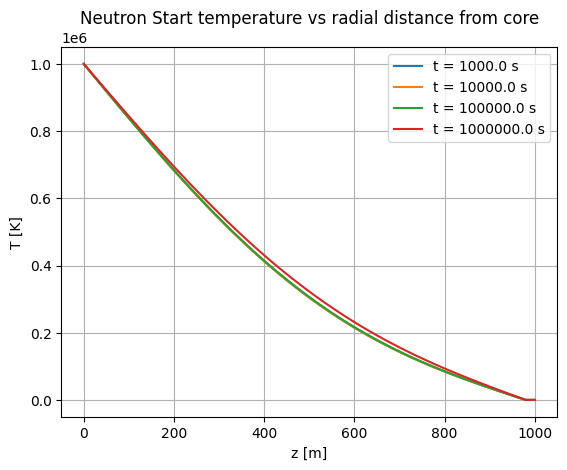

In [76]:
tiempos_salida = [1.e3, 1.e4, 1.e5, 1.e6]
T_history = []
F_history = []
t = 0.

for paso in range(1, n_steps + 1):
    a, b, c, rhs = construir_sistema(T.copy())

    T_interior = Thomas(a, b, c, rhs, N-2)

    T[1:N-2] = T_interior[1:N-2]
    T[0] = T_surf
    T[N-1] = T_core
    t = t + dt 

    # Diagnostico
    F_history.append((-alpha * (T[1] - T[0]) / dx, t))

    if t in tiempos_salida:
        print("Guardando snapshot de t=",t)
        T_history.append((T.copy(), t))

for (T_snap, t_snap) in T_history:
    plt.plot(x, T_snap, label = f"t = {t_snap} s")

plt.legend()
plt.grid()
plt.title("Neutron Start temperature vs radial distance from core")
plt.xlabel("z [m]")
plt.ylabel("T [K]")
plt.show()

Ahora, revisamos el diagnóstico del flujo de calor

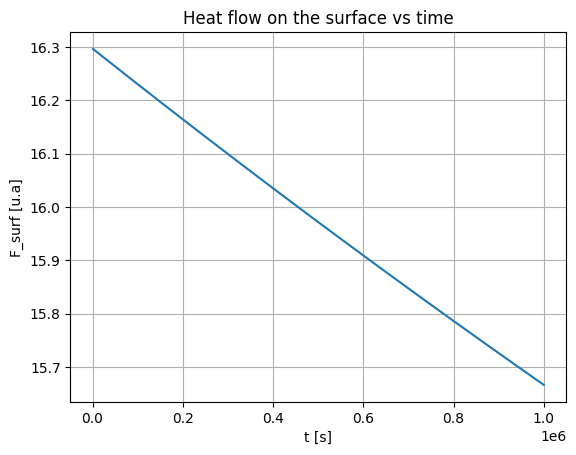

In [99]:
plt.plot(np.array(F_history)[::,1], np.array(F_history)[::,0])
plt.grid()
plt.title("Heat flow on the surface vs time")
plt.xlabel("t [s]")
plt.ylabel("F_surf [u.a]")
plt.show()